# Cohort Plot Gallery

Cohort plots visualise how groups of customers behave over time as a colour-coded grid: rows are cohorts (acquisition month, signup quarter), columns are periods since acquisition, and cells show the metric. The triangular shape comes from newer cohorts having fewer observed periods.

Cohort plots excel at:
- **Retention curves**: read the decay of each cohort across the row
- **Cohort comparison**: scan a column to compare cohorts at the same age
- **Promotion or seasonality effects**: spot which acquisition periods produced stickier customers
- **Revenue contribution**: track per-customer spend as cohorts mature

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from openretailscience.plots import cohort

In [ ]:
# Hand-crafted cohort datasets shared across the gallery examples.
# Newer cohorts have fewer observed periods, hence the NaN triangles.
# In both datasets the December 2024 cohort outperforms every other cohort
# at every age (the typical retail story for a holiday-acquired cohort).

# Retention rates: % of original cohort still active in month N after acquisition.
# fmt: off
retention_data = pd.DataFrame(
    {
        "M1": [0.78, 0.74, 0.71, 0.68, 0.82, 0.75, 0.72, 0.70],
        "M2": [0.62, 0.58, 0.55, 0.52, 0.69, 0.60, 0.57, None],
        "M3": [0.51, 0.47, 0.44, 0.41, 0.57, 0.49, None, None],
        "M4": [0.43, 0.39, 0.36, 0.33, 0.46, None, None, None],
        "M5": [0.37, 0.34, 0.31, 0.28, None, None, None, None],
        "M6": [0.32, 0.30, 0.27, None, None, None, None, None],
        "M7": [0.29, 0.28, None, None, None, None, None, None],
        "M8": [0.27, None, None, None, None, None, None, None],
    },
    index=[
        "Aug 2024", "Sep 2024", "Oct 2024", "Nov 2024",
        "Dec 2024", "Jan 2025", "Feb 2025", "Mar 2025",
    ],
)
# fmt: on

# Average revenue per active customer ($) by cohort and tenure.
# fmt: off
revenue_per_customer = pd.DataFrame(
    {
        "M1": [58, 61, 64, 67, 78, 69],
        "M2": [52, 54, 56, 58, 68, 60],
        "M3": [49, 50, 52, 53, 61, None],
        "M4": [46, 47, 48, None, None, None],
        "M5": [45, 45, None, None, None, None],
        "M6": [44, None, None, None, None, None],
    },
    index=["Aug 2024", "Sep 2024", "Oct 2024", "Nov 2024", "Dec 2024", "Jan 2025"],
)
# fmt: on

## Basic Retention Cohort

The default call: pass a wide-format DataFrame where the index is the cohort and the columns are periods since acquisition. Cells render as percentages by default (`percentage=True`), and column labels render at the top of the matrix to read naturally as a left-to-right time progression alongside the cohort labels.

---

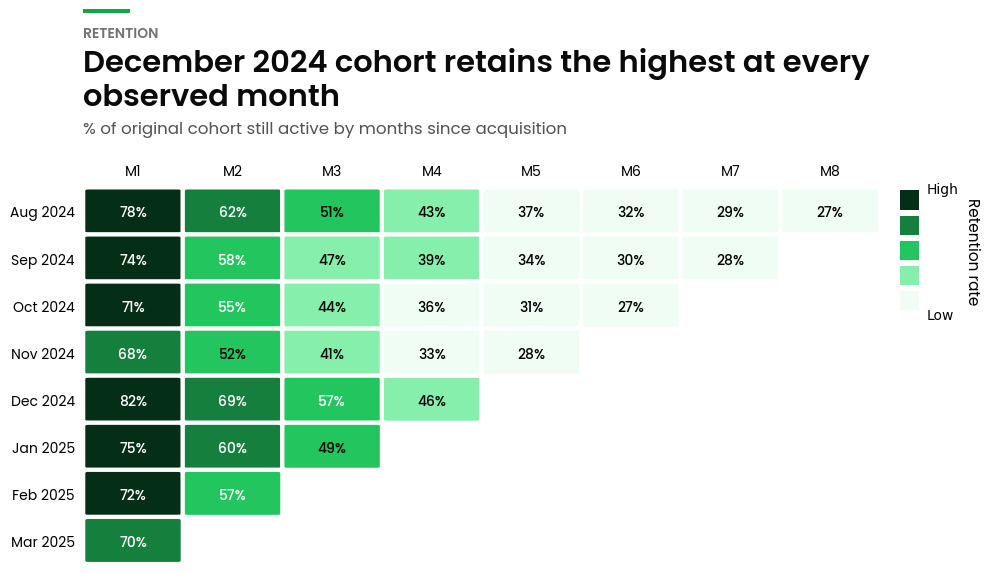

In [ ]:
cohort.plot(
    retention_data,
    cbar_label="Retention rate",
    eyebrow="Retention",
    title="December 2024 cohort retains the highest at every observed month",
    subtitle="% of original cohort still active by months since acquisition",
    figsize=(10, 6),
)
plt.show()

## Revenue Cohort

Set `percentage=False` to render raw values (rather than percentages) in each cell. Use this shape for any metric that isn't a rate, e.g. revenue per customer, orders per cohort, or average order value.

Internally this just swaps the cell format from `"{x:.0%}"` to `"{x:g}"`, which trims trailing zeros for a cleaner look.

---

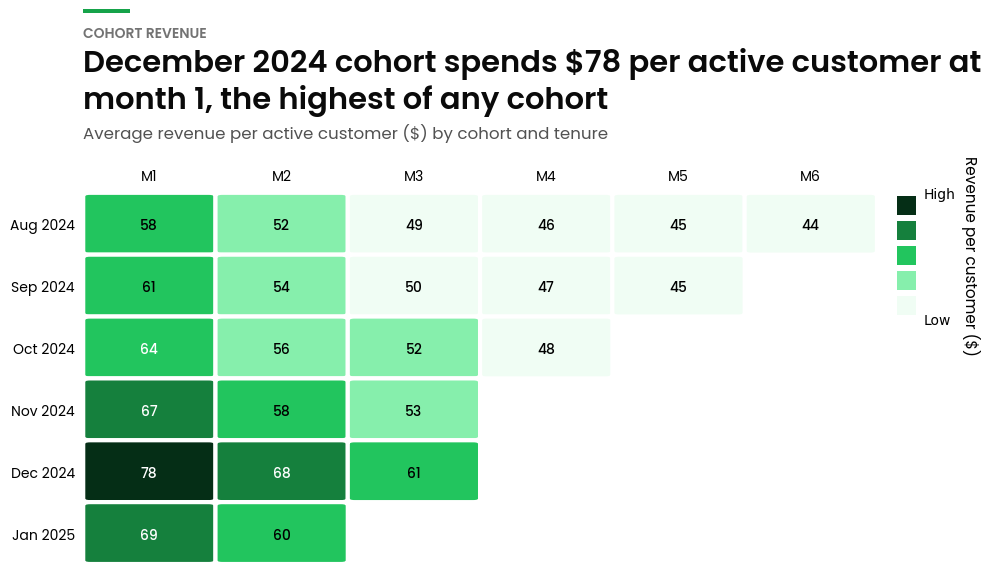

In [ ]:
cohort.plot(
    revenue_per_customer,
    cbar_label="Revenue per customer ($)",
    percentage=False,
    eyebrow="Cohort revenue",
    title="December 2024 cohort spends $78 per active customer at month 1, the highest of any cohort",
    subtitle="Average revenue per active customer ($) by cohort and tenure",
    figsize=(10, 6),
)
plt.show()

## Continuous Colormap

Pass `colormap_style="continuous"` to render the cohort grid with a smooth colour gradient instead of the default 5-bin stepped scale. Useful when retention differences between cohorts are small enough that the discrete bins lump them together.

---

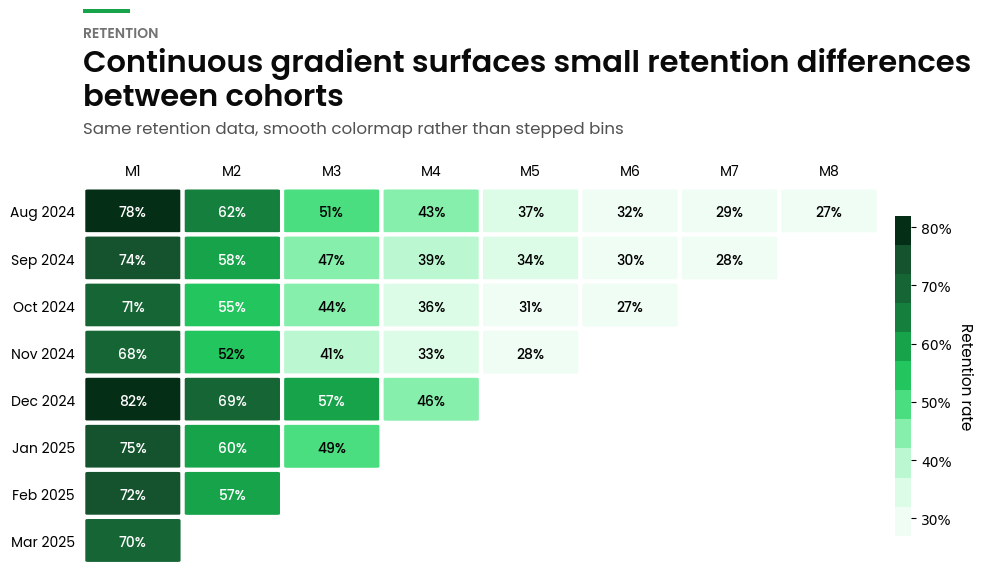

In [ ]:
cohort.plot(
    retention_data,
    cbar_label="Retention rate",
    colormap_style="continuous",
    eyebrow="Retention",
    title="Continuous gradient surfaces small retention differences between cohorts",
    subtitle="Same retention data, smooth colormap rather than stepped bins",
    figsize=(10, 6),
)
plt.show()

## Axis Labels and Source Attribution

Add `x_label`/`y_label` when the axis dimensions need explicit naming alongside the column and index headers, and `source_text` for an attribution line on export-ready images.

---

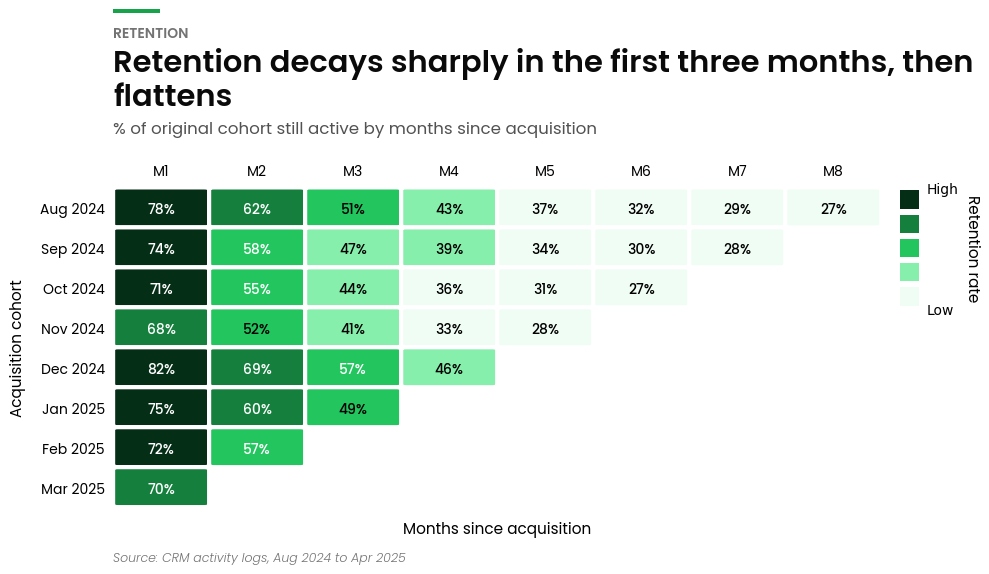

In [ ]:
cohort.plot(
    retention_data,
    cbar_label="Retention rate",
    x_label="Months since acquisition",
    y_label="Acquisition cohort",
    eyebrow="Retention",
    title="Retention decays sharply in the first three months, then flattens",
    subtitle="% of original cohort still active by months since acquisition",
    source_text="Source: CRM activity logs, Aug 2024 to Apr 2025",
    figsize=(10, 6),
)
plt.show()